In [1]:
%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\yushi\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import dataframe_image as dfi
import os

In [3]:
df = pd.read_csv("../data/final_dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (196943, 23)


,date,station,TMAX,state,id,elevation,disasters_count,heat_related_disaster_count,heat_related_area_count,heat_related_any,...,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum
0,2020-01-01,GHCND:USW00013876,56.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
1,2020-01-02,GHCND:USW00013876,70.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
2,2020-01-03,GHCND:USW00013876,65.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
3,2020-01-04,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0
4,2020-01-05,GHCND:USW00013876,57.0,AL,GHCND:USW00013876,187.7,0.0,0.0,0.0,0.0,...,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0


In [4]:
display(df.dtypes)

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values(by="missing_percent", ascending=False)

display(summary)

date                               object
station                            object
TMAX                              float64
state                              object
id                                 object
elevation                         float64
disasters_count                   float64
heat_related_disaster_count       float64
heat_related_area_count           float64
heat_related_any                  float64
heat_related_counties_affected    float64
state_fips                          int64
p_pov                             float64
p_unemp                           float64
p_nohsdp                          float64
p_uninsur                         float64
p_imperv                          float64
p_treec                           float64
p_age65                           float64
p_asthma                          float64
overall_score                     float64
hhb_score                         float64
pop_state_sum                     float64
dtype: object

,dtype,missing_values,missing_percent,unique_values
date,object,0,0.0,1827
p_pov,float64,0,0.0,40
hhb_score,float64,0,0.0,40
overall_score,float64,0,0.0,40
p_asthma,float64,0,0.0,40
p_age65,float64,0,0.0,40
p_treec,float64,0,0.0,40
p_imperv,float64,0,0.0,40
p_uninsur,float64,0,0.0,40
p_nohsdp,float64,0,0.0,40


In [4]:
data = df.copy()

# Convert date to datetime
data["date"] = pd.to_datetime(data["date"])

# Create numerical date features
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["dayofyear"] = data["date"].dt.dayofyear
data["dayofweek"] = data["date"].dt.dayofweek

# Select features for clustering
# Exclude categorical identifiers and target/disaster outcome columns
selected_features = [
    "TMAX",
    "elevation",
    "p_pov",
    "p_unemp",
    "p_nohsdp",
    "p_uninsur",
    "p_imperv",
    "p_treec",
    "p_age65",
    "p_asthma",
    "overall_score",
    "hhb_score",
    "pop_state_sum",
    "year",
    "month",
    "dayofyear",
    "dayofweek"
]

X = data[selected_features].copy()

print("Selected features shape:", X.shape)
display(X.head())

Selected features shape: (196943, 17)


,TMAX,elevation,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,dayofyear,dayofweek
0,56.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,1,2
1,70.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,2,3
2,65.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,3,4
3,57.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,4,5
4,57.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,5,6


In [5]:
print("Before preprocessing:")
dfi.export(
    X.head(10), 
    "../../website/resources/img/tables/cluster_raw_table.png",
    table_conversion="chrome",
    max_cols = 10
)
display(X.head(10))

Before preprocessing:


,TMAX,elevation,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,dayofyear,dayofweek
0,56.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,1,2
1,70.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,2,3
2,65.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,3,4
3,57.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,4,5
4,57.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,5,6
5,66.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,6,0
6,58.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,7,1
7,63.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,8,2
8,64.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,9,3
9,69.0,187.7,25.905201,5.914988,13.554414,9.515623,9.743966,46.650189,16.499473,10.640051,0.49457,0.394871,4844696.0,2020,1,10,4


In [6]:
preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = preprocessor.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

print("After preprocessing (scaled features):")

dfi.export(
    scaled_df.head(10),
    "../../website/resources/img/tables/cluster_clean_table.png",
    table_conversion="chrome",
    max_cols = 10
)

display(scaled_df.head(10))

print("Scaled data shape:", X_scaled.shape)

After preprocessing (scaled features):


,TMAX,elevation,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,dayofyear,dayofweek
0,-0.157713,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.725118,-0.500092
1,0.518730,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.715637,-0.000127
2,0.277144,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.706155,0.499838
3,-0.109395,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.696673,0.999803
4,-0.109395,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.687191,1.499768
5,0.325461,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.677709,-1.500022
6,-0.061078,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.668227,-1.000057
7,0.180509,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.658745,-0.500092
8,0.228826,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.649263,-0.000127
9,0.470413,-0.902168,1.364262,1.128958,1.301166,0.562997,-0.916031,1.501994,0.360543,0.275185,-0.44112,-0.581203,-0.034793,-1.406929,-1.598408,-1.639781,0.499838


Scaled data shape: (196943, 17)


In [8]:
# Use a sample for faster model selection
sample_size = min(20000, len(X_scaled))
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

print("Sample shape used for selecting k:", X_sample.shape)

Sample shape used for selecting k: (20000, 17)


In [9]:
results = []

k_values = range(2, 12)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_sample)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_sample, cluster_labels)
    db_index = davies_bouldin_score(X_sample, cluster_labels)
    
    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette,
        "davies_bouldin_index": db_index
    })

results_df = pd.DataFrame(results)
display(results_df)

,k,inertia,silhouette_score,davies_bouldin_index
0,2,289094.073484,0.159301,2.276991
1,3,258119.530790,0.146949,1.975510
2,4,239683.636273,0.157533,2.181424
3,5,220303.479686,0.171700,1.928545
4,6,203429.595142,0.190697,1.814748
5,7,188010.942081,0.199673,1.685726
6,8,171413.486372,0.213969,1.509386
7,9,160682.934239,0.227021,1.493251
8,10,154426.396459,0.222337,1.537257
9,11,149389.083259,0.204871,1.529917


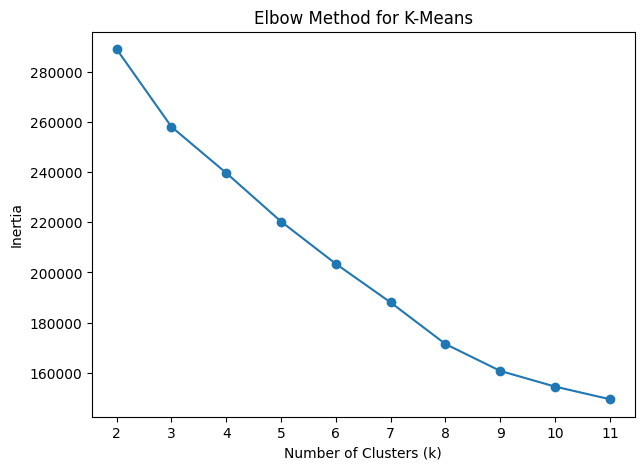

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(results_df["k"])
plt.savefig('../../website/resources/img/plots/clustering_elbow.png')
plt.show()

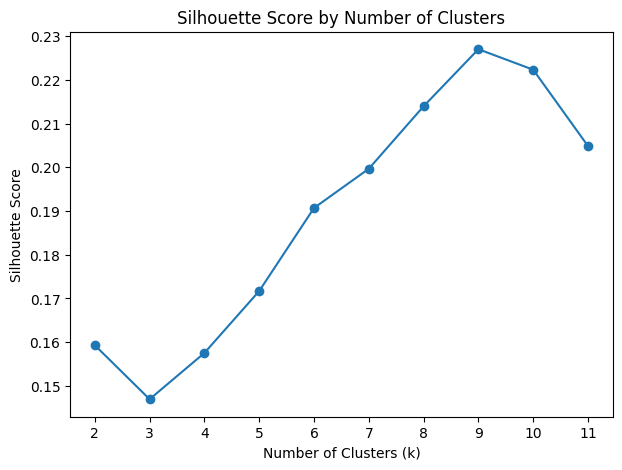

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(results_df["k"])
plt.savefig('../../website/resources/img/plots/clustering_silhouette.png')
plt.show()

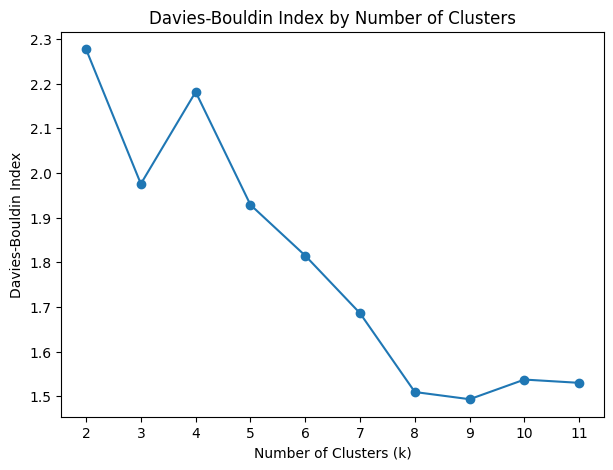

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(results_df["k"], results_df["davies_bouldin_index"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index by Number of Clusters")
plt.xticks(results_df["k"])
plt.savefig('../../website/resources/img/plots/clustering_db_index.png')
plt.show()

In [13]:
# Choose the k with the highest silhouette score
best_k = int(results_df.loc[results_df["silhouette_score"].idxmax(), "k"])

print("Best k based on highest silhouette score:", best_k)

# You can also manually change this if you prefer based on elbow + DB index

Best k based on highest silhouette score: 9


In [14]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

data["cluster"] = cluster_labels

print("Cluster labels added to dataset.")
display(data[["cluster"]].head())

Cluster labels added to dataset.


,cluster
0,1
1,1
2,1
3,1
4,1


In [15]:
# Use the same sample size for evaluation to keep runtime manageable
eval_idx = np.random.RandomState(42).choice(len(X_scaled), size=sample_size, replace=False)
X_eval = X_scaled[eval_idx]
labels_eval = cluster_labels[eval_idx]

final_silhouette = silhouette_score(X_eval, labels_eval)
final_db_index = davies_bouldin_score(X_eval, labels_eval)

print("Final Clustering Evaluation")
print("Best k:", best_k)
print("Silhouette Score:", round(final_silhouette, 4))
print("Davies-Bouldin Index:", round(final_db_index, 4))
print("Inertia:", round(final_kmeans.inertia_, 4))

Final Clustering Evaluation
Best k: 9
Silhouette Score: 0.227
Davies-Bouldin Index: 1.4933
Inertia: 1583681.4915


Cluster sizes:


cluster
0    24143
1    31343
2    14603
3    30808
4    14611
5    31038
6    32307
7     1826
8    16264
Name: count, dtype: int64

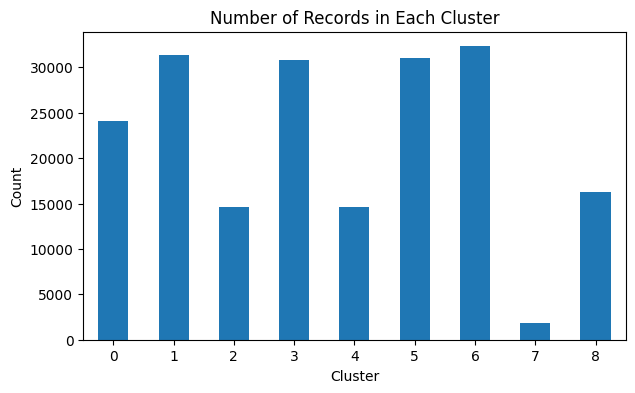

In [17]:
cluster_counts = data["cluster"].value_counts().sort_index()

print("Cluster sizes:")
display(cluster_counts)

plt.figure(figsize=(7, 4))
cluster_counts.plot(kind="bar")
plt.title("Number of Records in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.savefig('../../website/resources/img/plots/clustering_cluster_counts.png')
plt.show()

In [18]:
cluster_profile = data.groupby("cluster")[selected_features].mean().round(3)

print("Cluster profile (mean values):")
display(cluster_profile)

Cluster profile (mean values):


,TMAX,elevation,p_pov,p_unemp,p_nohsdp,p_uninsur,p_imperv,p_treec,p_age65,p_asthma,overall_score,hhb_score,pop_state_sum,year,month,dayofyear,dayofweek
cluster,,,,,,,,,,,,,,,,,
0,60.316,245.187,16.589,3.819,7.768,5.257,19.118,23.619,15.950,9.946,0.431,0.594,5.544667e+06,2021.983,6.529,183.442,3.001
1,73.316,258.864,25.990,5.604,13.107,10.054,11.985,37.498,16.105,10.701,0.536,0.406,4.660498e+06,2021.969,6.501,182.585,3.000
2,55.019,390.982,12.772,3.640,5.272,5.691,11.294,56.349,18.216,11.288,0.420,0.750,1.145303e+06,2022.000,6.522,183.239,3.000
3,54.015,2603.611,17.239,3.956,8.114,8.781,25.355,9.026,12.174,10.340,0.564,0.711,3.715753e+06,2022.011,6.500,182.557,3.001
4,68.413,466.572,21.866,5.913,13.253,8.271,35.055,14.998,16.329,9.611,0.515,0.448,2.125482e+07,2022.000,6.523,183.244,3.000
5,51.989,1909.248,20.850,4.104,7.384,9.841,5.783,10.373,16.975,10.150,0.520,0.599,1.023024e+06,2022.000,6.521,183.200,3.000
6,57.122,714.358,19.238,5.514,9.371,5.152,28.346,28.198,15.881,11.181,0.548,0.606,5.673493e+06,2021.992,6.497,182.447,3.000
7,54.607,455.700,8.627,1.403,7.301,5.753,10.122,2.021,15.378,9.148,0.478,-1.993,6.862680e+05,2022.000,6.522,183.218,3.001
8,54.822,2325.319,23.941,5.902,14.046,10.609,35.163,2.072,16.032,10.236,0.685,0.718,3.432020e+06,2022.000,6.531,183.489,3.001


In [19]:
heat_rate_by_cluster = data.groupby("cluster")["heat_related_any"].mean().round(4)

print("Heat-related event rate by cluster:")
display(heat_rate_by_cluster)

Heat-related event rate by cluster:


cluster
0    0.0012
1    0.0048
2    0.0029
3    0.0044
4    0.0114
5    0.0049
6    0.0105
7    0.0027
8    0.0088
Name: heat_related_any, dtype: float64

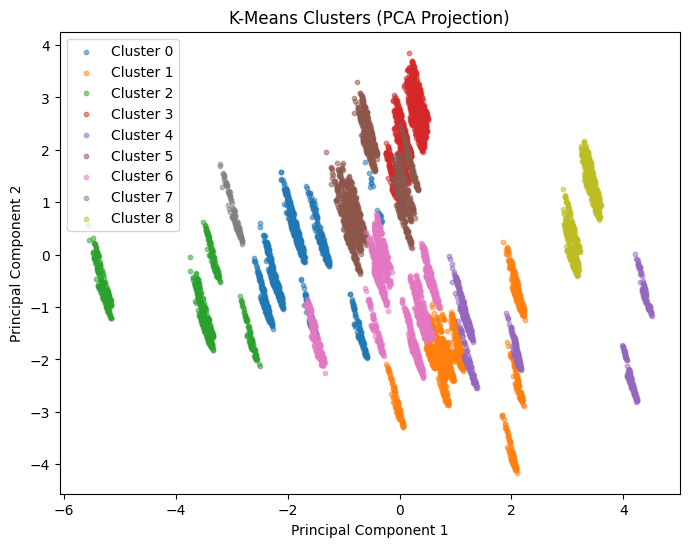

In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels
})

# Plot only a sample for faster rendering
plot_sample = pca_df.sample(min(10000, len(pca_df)), random_state=42)

plt.figure(figsize=(8, 6))
for c in sorted(plot_sample["cluster"].unique()):
    cluster_data = plot_sample[plot_sample["cluster"] == c]
    plt.scatter(cluster_data["PC1"], cluster_data["PC2"], s=10, alpha=0.5, label=f"Cluster {c}")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.legend()
plt.savefig('../../website/resources/img/plots/clustering_pca.png')
plt.show()

## Discussion for Report

### Why K-Means was chosen
K-Means was selected because it is a simple and efficient unsupervised learning algorithm for identifying natural groupings in large tabular datasets. This dataset contains many continuous numerical variables related to temperature, elevation, vulnerability, asthma prevalence, tree cover, and other environmental and social indicators, so it was appropriate to explore whether similar observations could be grouped into clusters without using the target variable. K-Means was especially useful here because the goal was to discover hidden structure in the data and then compare how heat-related outcomes differed across those groups.

### Preprocessing before clustering
Before applying K-Means, the data was transformed so that it matched the requirements of the algorithm. The original `date` column was converted into numerical time-based features: `year`, `month`, `dayofyear`, and `dayofweek`. Only numerical variables were kept for clustering, resulting in 17 selected features. Categorical identifier columns such as `station`, `state`, and `id` were excluded because K-Means relies on Euclidean distance and cannot directly interpret text-based categories meaningfully. Target and disaster-related outcome columns such as `heat_related_any`, `heat_related_disaster_count`, and related heat event counts were also excluded so that the clustering process remained fully unsupervised. Missing values were handled with median imputation, and all features were standardized using `StandardScaler` so that variables measured on different scales, such as `TMAX`, `elevation`, and population-based indicators, contributed more fairly to the clustering process.

### Hyperparameter tuning and model evaluation
The main hyperparameter tuned for K-Means was the number of clusters, `k`. A sample of 20,000 observations was used to test values from `k = 2` to `k = 11` in order to reduce runtime while still evaluating the structure of the data. The model was assessed using the Elbow Method, Silhouette Score, and Davies-Bouldin Index. Among the tested values, `k = 9` produced the best clustering quality with the highest Silhouette Score of **0.2270** and the lowest Davies-Bouldin Index of **1.4933**, so it was selected as the final model. The final model also produced an inertia value of **1,583,681.4915**. Although the Silhouette Score is not very high, it still suggests that there is some meaningful cluster structure in the dataset, while also indicating that the clusters are only moderately separated rather than perfectly distinct.

### Interpretation of clustering results
The final K-Means model created 9 clusters with uneven cluster sizes, ranging from **1,826** records in Cluster 7 to **32,307** records in Cluster 6. After clustering, the target variable `heat_related_any` was used only for interpretation, not for training. The heat-related event rate varied noticeably across clusters, showing that the clusters captured meaningful differences in risk. The highest heat-related rates appeared in **Cluster 4 (0.0114)**, **Cluster 6 (0.0105)**, and **Cluster 8 (0.0088)**, while the lowest rate appeared in **Cluster 0 (0.0012)**. These higher-risk clusters generally showed combinations of elevated temperature, higher poverty or vulnerability measures, and in some cases higher impervious surface percentages, suggesting that both environmental exposure and social vulnerability may contribute to greater heat-related risk. Overall, the K-Means model was useful for segmenting the data into interpretable groups, even though the separation between clusters was moderate rather than strong.